<a href="https://colab.research.google.com/github/IvankoPilotOfHalychyna/Foundations_AI/blob/main/Tutorial7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 7

## Introduction

### Data Scaling

Data scaling is the process of transforming feature values so that they fall within a similar range.  
The goal is to improve the performance of learning algorithms (e.g., linear regression, k-NN, SVM), which are sensitive to differences in data scale.

<br>

Scaling **does not change the shape of the data distribution**, but it ensures feature comparability, which **speeds up and stabilizes** the model training process.


#### The most common scaling methods

##### **Standardization (Z-score Normalization)**

Transforms the data so that it has a **mean of 0** and a **standard deviation of 1**:

$$
x' = \frac{x - \mu}{\sigma}
$$

where:  
- $ x $ – original value,  
- $ \mu $ – mean of the feature values,  
- $ \sigma $ – standard deviation.


##### **Normalization (Min-Max Scaling)**

Transforms the data into a specified range (usually $ [0, 1] $):

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

where:  
- $ x_{\min} $, $ x_{\max} $ – minimum and maximum values of the feature.


##### **MaxAbs Scaling**

Used for data containing negative values; scales the data to the range $ [-1, 1] $:

$$
x' = \frac{x}{|x_{\max}|}
$$


#### Example of Data Scaling in Python

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

data = {
    'Height': [160, 170, 180, 190],
    'Weight': [55, 65, 80, 95]
}

df = pd.DataFrame(data)
print(df)

# Standardization (mean = 0, std deviation = 1)
scaler_std = StandardScaler()
df_standard = pd.DataFrame(scaler_std.fit_transform(df), columns=df.columns)

print("\nData after standardization:")
print(df_standard)

# Normalization (range [0, 1])
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df), columns=df.columns)

print("\nData after normalization:")
print(df_minmax)


   Height  Weight
0     160      55
1     170      65
2     180      80
3     190      95

Data after standardization:
     Height    Weight
0 -1.341641 -1.237179
1 -0.447214 -0.577350
2  0.447214  0.412393
3  1.341641  1.402136

Data after normalization:
     Height  Weight
0  0.000000   0.000
1  0.333333   0.250
2  0.666667   0.625
3  1.000000   1.000


### Nueral network

#### What is a Neural Network?
A **neural network** is a mathematical model inspired by the way the biological brain works,  
used for pattern recognition and data processing. It consists of layers of interconnected  
**neurons** (nodes) that transform input data into output data.

A neural network is made up of connected “neurons” (simple computational units) arranged in layers:

- Input layer – receives data (e.g., image pixels, numbers, text).

- Hidden layers – process the data, learning complex relationships and patterns.

- Output layer – produces the result (e.g., class label, predicted value, text response).


#### Activation Functions (Examples)

- Sigmoid function:
  $$
  f(x) = \frac{1}{1 + e^{-x}}
  $$

**Range:** $(0, 1)$

**Advantages:**  
Can be interpreted as a “probability.”

**Disadvantages:**  
Performs poorly with large positive/negative values (vanishing gradient problem).

**Usage:**  
Often used in the output layer for binary classification.

<br>

- ReLU function:
  $$
  f(x) = \max(0, x)
  $$

**Range:** $[0, ∞)$

**Advantages:**  
Fast, simple, and highly effective.  
Helps avoid the vanishing gradient problem.

**Disadvantages:**  
Can cause so-called dead neurons (when weights make the neuron always output 0).

**Usage:**  
Most commonly used in hidden layers of deep networks (CNN, MLP).

<br>

- Softmax

$$
f(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}
$$

**Range:** $(0, 1)$, and the sum of all outputs = $1$

**Description:**  
Converts a vector of values into a probability distribution.

**Usage:**  
Used in the output layer for multi-class classification (e.g., recognizing digits 0–9).


#### Training a Neural Network

Training involves minimizing the error between the predicted and actual output using the  
**backpropagation** algorithm and optimization methods, e.g., **gradient descent**.

$$
w_i \leftarrow w_i - \eta \frac{\partial L}{\partial w_i}
$$

where:  
- $ \eta $ – learning rate,  
- $ L $ – loss function.

#### How a Neural Network Learns to Solve Tasks

The process of training a neural network can be divided into several steps:

#### a) Forward Propagation

- Input data passes through the network.  
- Each neuron computes its weighted sum and applies an activation function.  
- The output (prediction) is obtained.  

#### b) Error Calculation

- Compare the network's output with the actual response (label).  
- Use a loss function, e.g., MSE for regression or cross-entropy for classification.  

#### c) Backpropagation

- Compute gradients of the loss function with respect to the weights.  
- Weights are updated to minimize the error (e.g., using gradient descent or an optimizer like Adam).  

#### d) Weight Update

Weights are updated according to the rule:

$$
w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial L}{\partial w}
$$

where:  

- $\eta$ — learning rate,  
- $L$ — loss function.  

#### Example of Multi-Class Classification Using a Neural Network in Python

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLP model
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, activation='relu', random_state=42)

# Train the model
mlp.fit(X_train, y_train)

# Predict and evaluate
y_pred = mlp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9666666666666667
Confusion matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



#### Example of Multi-Class Classification in Python (Keras)


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

iris = load_iris()
X = iris.data
y = iris.target

y = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build MLP model
model = Sequential()
model.add(Dense(10, input_shape=(4,), activation='relu'))  # hidden layer 1
model.add(Dense(8, activation='relu'))                     # hidden layer 2
model.add(Dense(3, activation='softmax'))                 # output layer (3 classes)

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=5,
                    verbose=1)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2712 - loss: 1.3881 - val_accuracy: 0.3750 - val_loss: 1.1759
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3153 - loss: 1.1816 - val_accuracy: 0.3333 - val_loss: 1.0992
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2149 - loss: 1.1158 - val_accuracy: 0.2917 - val_loss: 1.0381
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2929 - loss: 1.0031 - val_accuracy: 0.5417 - val_loss: 0.9911
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5940 - loss: 0.9713 - val_accuracy: 0.5833 - val_loss: 0.9487
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8139 - loss: 0.8906 - val_accuracy: 0.6250 - val_loss: 0.9079
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7474 - loss: 0.8705 - val_accuracy: 0.6250 - val_loss: 0.8690
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7879 - loss: 0.7717 - val_accuracy: 0.7083 - 

## Exercise
For the `load_digits` dataset from the `sklearn.datasets` module, perform EDA (Exploratory Data Analysis) and classify the `target` feature (digits 0-9) using a neural network.

Example of loading data:
```
import pandas as pd
from sklearn.datasets import load_digits

data = load_digits()

X = digits.data       # features (64 piksele)
y = digits.target     # labels (cyfry 0-9)
```

Remember to:
- check for missing data,
- check for correlation between features,
- identify outliers,
- validate the model using metrics,
- visualize the data and results.


## 1. Load Dataset



In [1]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 elements of X:\n", X[:5])
print("First 5 elements of y:", y[:5])

Shape of X: (1797, 64)
Shape of y: (1797,)
First 5 elements of X:
 [[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
  15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
   0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
   0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
 [ 0.  0.  0. 12. 13.  5.  0.  0.  0.  0.  0. 11. 16.  9.  0.  0.  0.  0.
   3. 15. 16.  6.  0.  0.  0.  7. 15. 16. 16.  2.  0.  0.  0.  0.  1. 16.
  16.  3.  0.  0.  0.  0.  1. 16. 16.  6.  0.  0.  0.  0.  1. 16. 16.  6.
   0.  0.  0.  0.  0. 11. 16. 10.  0.  0.]
 [ 0.  0.  0.  4. 15. 12.  0.  0.  0.  0.  3. 16. 15. 14.  0.  0.  0.  0.
   8. 13.  8. 16.  0.  0.  0.  0.  1.  6. 15. 11.  0.  0.  0.  1.  8. 13.
  15.  1.  0.  0.  0.  9. 16. 16.  5.  0.  0.  0.  0.  3. 13. 16. 16. 11.
   5.  0.  0.  0.  0.  3. 11. 16.  9.  0.]
 [ 0.  0.  7. 15. 13.  1.  0.  0.  0.  8. 13.  6. 15.  4.  0.  0.  0.  2.
   1. 13. 13.  0.  0.  0.  0.  0.  2. 15. 11.  1.  0.  0.  0.  0

## 2. EDA


In [2]:
import numpy as np

missing_X = np.isnan(X).sum()
missing_y = np.isnan(y).sum()

print(f"Missing values in X: {missing_X}")
print(f"Missing values in y: {missing_y}")

Missing values in X: 0
Missing values in y: 0


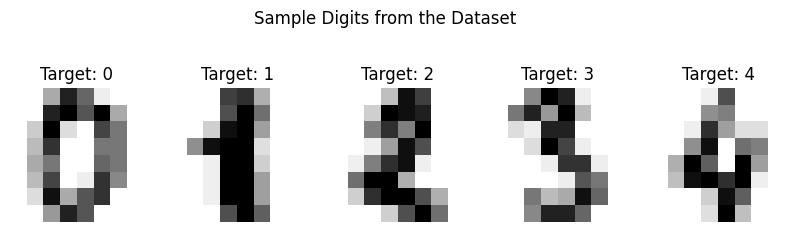

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3))
for ax, image, label in zip(axes, X, y):
    ax.set_axis_off()
    ax.imshow(image.reshape((8, 8)), cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Target: {label}')
plt.suptitle('Sample Digits from the Dataset', y=0.98)
plt.show()

In [4]:
import pandas as pd

digit_distribution = pd.Series(y).value_counts().sort_index()
print("Distribution of digits in the dataset:\n", digit_distribution)

Distribution of digits in the dataset:
 0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


### Observations from EDA

1.  **Missing Data**: There are no missing values in either the feature data (`X`) or the target labels (`y`), indicating a clean dataset.
2.  **Pixel Values**: The sample digits visualized show varying shades, implying pixel values are not just binary (0 or 1) but span a range. The `X` array contains floating-point numbers, confirming this, typically ranging from 0 to 16 for these grayscale images.
3.  **Class Distribution**: The distribution of digits (0-9) in the dataset is relatively balanced. Each digit appears approximately 174-183 times, which is good for training a classification model as it avoids significant class imbalance issues.

## 3. Data preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("First 5 scaled elements of X_train_scaled:\n", X_train_scaled[:5])

## 4. Neural Network Model

In [6]:
from sklearn.neural_network import MLPClassifier

# Create MLP model with appropriate hidden layers and activation function
# The input layer size is implicitly determined by the training data's features (64)
# The output layer size is implicitly determined by the number of unique classes in y (10 digits)
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, activation='relu', solver='adam', random_state=42, verbose=True)

# Train the model
mlp.fit(X_train_scaled, y_train)

print("Neural Network training complete.")

Iteration 1, loss = 2.30180916
Iteration 2, loss = 1.83311251
Iteration 3, loss = 1.47204901
Iteration 4, loss = 1.14654729
Iteration 5, loss = 0.86210269
Iteration 6, loss = 0.64158052
Iteration 7, loss = 0.48680951
Iteration 8, loss = 0.37467952
Iteration 9, loss = 0.29423584
Iteration 10, loss = 0.23779840
Iteration 11, loss = 0.19660288
Iteration 12, loss = 0.16628530
Iteration 13, loss = 0.14298970
Iteration 14, loss = 0.12534698
Iteration 15, loss = 0.11054576
Iteration 16, loss = 0.09849968
Iteration 17, loss = 0.08855447
Iteration 18, loss = 0.07994731
Iteration 19, loss = 0.07253947
Iteration 20, loss = 0.06609728
Iteration 21, loss = 0.06019899
Iteration 22, loss = 0.05570909
Iteration 23, loss = 0.05077967
Iteration 24, loss = 0.04664446
Iteration 25, loss = 0.04311899
Iteration 26, loss = 0.04012782
Iteration 27, loss = 0.03720620
Iteration 28, loss = 0.03458124
Iteration 29, loss = 0.03241414
Iteration 30, loss = 0.03015981
Iteration 31, loss = 0.02835142
Iteration 32, los

## 5. Model Evaluation

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on the scaled test data
y_pred = mlp.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9777777777777777

Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  1  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 35  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  3  1  0  0  0  0  1 30  0]
 [ 0  0  0  0  0  0  0  0  1 35]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.97      1.00      0.99        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.86      0.90        35
           9       1.00      0.97      0.99        36


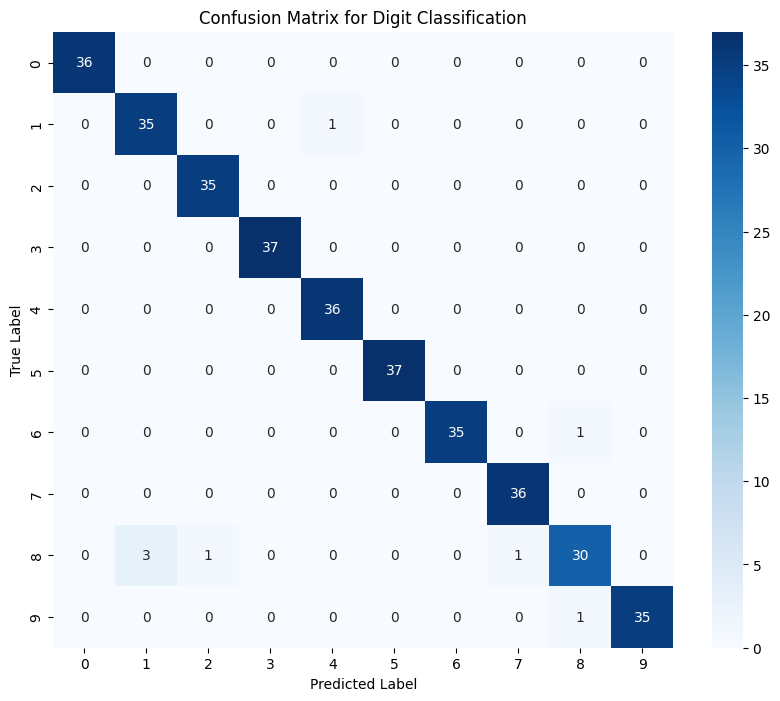

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Digit Classification')
plt.show()

## 6. Visualize Training History



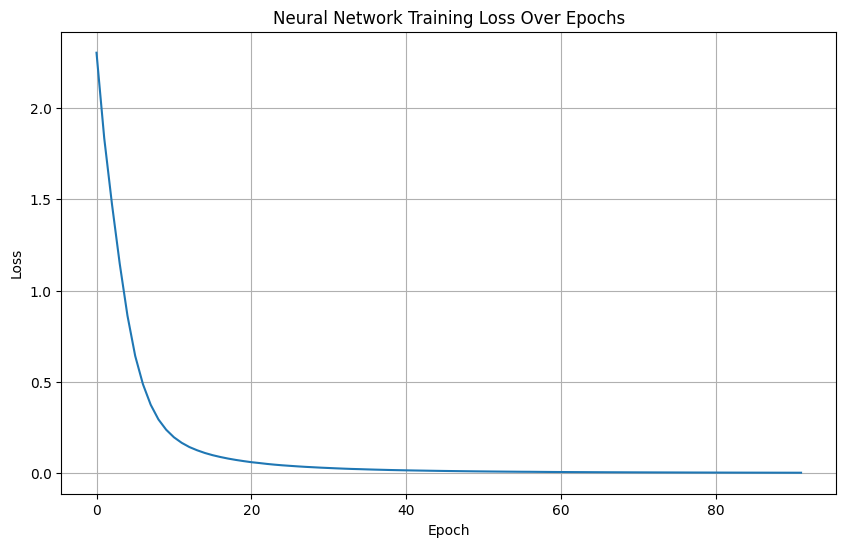

In [9]:
import matplotlib.pyplot as plt

# Access the loss curve from the trained MLP model
loss_curve = mlp.loss_curve_

# Create a line plot to visualize the training loss
plt.figure(figsize=(10, 6))
plt.plot(loss_curve)
plt.title('Neural Network Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


## Summary:

### Data Analysis Key Findings

*   **Dataset Overview**: The `load_digits` dataset contains 1797 samples, each with 64 features (representing an 8x8 grayscale image) and a corresponding target label (digit 0-9).
*   **Data Quality**: There are no missing values in either the feature data (`X`) or the target labels (`y`), indicating a clean dataset.
*   **Pixel Characteristics**: Visual inspection of sample digits revealed that pixel values are not binary but span a range (typically 0-16 for these grayscale images), representing varying shades.
*   **Class Distribution**: The distribution of digits (0-9) in the dataset is well-balanced, with each digit appearing approximately 174-183 times, which is favorable for classification tasks.
*   **Data Preprocessing**: The data was split into training (1437 samples) and testing (360 samples) sets using an 80/20 ratio with stratification. Feature scaling was applied using `StandardScaler` to normalize the pixel values.
*   **Model Performance**: The `MLPClassifier` achieved an accuracy of approximately 97.78% on the test set.
*   **Classification Details**: The confusion matrix and classification report indicated strong performance across most classes. Specific misclassifications were observed, such as digit 1 sometimes being predicted as 4, and digit 8 having several misclassifications (e.g., predicted as 1, 2, or 7).
*   **Training History**: The training loss curve showed a consistent decrease over 92 epochs, indicating that the model successfully learned from the training data and converged.

### Insights or Next Steps

*   Further investigate the specific misclassifications identified in the confusion matrix (e.g., why digit 8 is often confused with 1, 2, or 7). This could involve analyzing the visual characteristics of these misclassified samples.
*   Experiment with different neural network architectures (e.g., number of hidden layers, neurons per layer) and hyperparameters (e.g., learning rate, activation functions) to potentially improve accuracy and robustness, especially for the slightly less accurately classified digits.
